In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path
import ee
from loguru import logger

In [2]:
ee.Initialize()

S2_COLLECTION = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterDate(
    "2020-01-01", "2020-12-31"
)

In [3]:
def load_data():
    # get all index files
    index_files = glob.glob(
        "../../data/gee_pipeline/outputs/s2_indices_per_mgrs_tile/s2-indices_2020_*_v03.txt"
    )

    # filter out all the files that that are empty
    index_files = [f for f in index_files if Path(f).stat().st_size > 0]

    # create a list of dataframes
    dfs = [pd.read_table(f, header=None) for f in index_files]

    # concatenate all dataframes into a single dataframe
    df = pd.concat(dfs)
    df.columns = ["system:index"]
    df["tile"] = df["system:index"].str.split("_").str[2]
    df["date"] = df["system:index"].str.split("_").str[0]

    # filter all dates in 2020
    df = df[df["date"].str.contains("2020")]
    df["tile"] = df["tile"].str[1:]

    print(f"Number of images: {df.shape[0]}")
    # sample one row per tile
    df = df.drop_duplicates(subset=["tile"])

    return df

In [4]:
def compute_features(fc):
    fc_computed = ee.data.computeFeatures({"expression": fc})

    total_features_retrieved = len(fc_computed.get("features", {}))
    if total_features_retrieved == 0:
        logger.error("Empty feature collection; after grouping.")
    if "nextPageToken" in fc_computed:
        logger.debug(
            f"Partial retrieval of {total_features_retrieved} features. Fetching the rest."
        )
        fc_list = [fc_computed]
        while "nextPageToken" in fc_computed:
            fc_computed = ee.data.computeFeatures(
                {"expression": fc, "pageToken": fc_computed["nextPageToken"]}
            )
            fc_list.append(fc_computed)
            total_features_retrieved += len(fc_computed["features"])
            logger.debug(
                f"Partial retrieval of {total_features_retrieved} features. Fetching the rest."
            )
        logger.debug(f"Total features retrieved: {total_features_retrieved}")
        fc_concat = {
            "type": "FeatureCollection",
            "features": [feature for fc in fc_list for feature in fc["features"]],
        }
    else:
        logger.debug(f"Total features retrieved: {total_features_retrieved}")
        fc_concat = fc_computed

    return fc_concat

In [5]:
def get_s2_lat_lon_from_system_indices(list_indices: list[str]) -> pd.DataFrame:
    # convert list of system indices to a list of ee.List
    list_indices = ee.List(list_indices)

    # filter s2 collection by list of system indices
    s2_imgc = S2_COLLECTION.filter(ee.Filter.inList("system:index", list_indices))

    # get the centroid and return as feature collection
    s2_imgc_centroid = s2_imgc.map(
        lambda img: ee.Feature(
            None, {"centroid": img.geometry().centroid(), "date": img.date()}
        )
    )

    # compute the features
    # s2_imgc_centroid_computed = ee.data.computeFeatures(
    #     {"expression": s2_imgc_centroid}
    # )

    s2_imgc_centroid_computed = compute_features(s2_imgc_centroid)

    # get the features
    features = s2_imgc_centroid_computed.get("features", {})
    if len(features) == 0:
        logger.error("Empty feature collection")
        return pd.DataFrame()

    # convert feature collection to pandas dataframe using geojson format
    features = [
        feature["properties"]
        for feature in features
        if "properties" in feature
        and "centroid" in feature["properties"]
        and "coordinates" in feature["properties"]["centroid"]
    ]

    df = pd.DataFrame(features)
    df["centroid"] = df["centroid"].apply(lambda x: x["coordinates"])
    df[["lon", "lat"]] = pd.DataFrame(df["centroid"].tolist(), index=df.index)
    df = df.drop(columns=["centroid"])

    return df

In [6]:
df = load_data()

Number of images: 151668


In [7]:
df

,system:index,tile,date
0,20200316T124039_20200316T124038_T26SMH,26SMH,20200316T124039
5,20200316T124039_20200316T124038_T26SMJ,26SMJ,20200316T124039
10,20201211T124039_20201211T124037_T26SNG,26SNG,20201211T124039
15,20200220T124031_20200220T124034_T26SNH,26SNH,20200220T124031
20,20200220T124031_20200220T124034_T26SPF,26SPF,20200220T124031
...,...,...,...
48,20201001T162019_20201001T163419_T16RDV,16RDV,20201001T162019
53,20201001T162019_20201001T163419_T16REU,16REU,20201001T162019
58,20201001T162019_20201001T163419_T16REV,16REV,20201001T162019
106,20201029T163421_20201029T163843_T16RCU,16RCU,20201029T163421


In [8]:
system_indices = df["system:index"].tolist()
fc = get_s2_lat_lon_from_system_indices(system_indices)

2026-04-07 15:20:50.095 | DEBUG    | __main__:compute_features:8 - Partial retrieval of 1000 features. Fetching the rest.
2026-04-07 15:20:58.573 | DEBUG    | __main__:compute_features:18 - Partial retrieval of 2000 features. Fetching the rest.
2026-04-07 15:21:07.009 | DEBUG    | __main__:compute_features:18 - Partial retrieval of 3000 features. Fetching the rest.
2026-04-07 15:21:14.947 | DEBUG    | __main__:compute_features:18 - Partial retrieval of 4000 features. Fetching the rest.
2026-04-07 15:21:21.433 | DEBUG    | __main__:compute_features:18 - Partial retrieval of 5000 features. Fetching the rest.
2026-04-07 15:21:25.827 | DEBUG    | __main__:compute_features:18 - Partial retrieval of 6000 features. Fetching the rest.
2026-04-07 15:21:32.195 | DEBUG    | __main__:compute_features:18 - Partial retrieval of 7000 features. Fetching the rest.
2026-04-07 15:21:38.877 | DEBUG    | __main__:compute_features:18 - Partial retrieval of 8000 features. Fetching the rest.
2026-04-07 15:21:

In [9]:
fc

,date,lon,lat
0,"{'type': 'Date', 'value': 1577837943100}",152.444720,-8.612546
1,"{'type': 'Date', 'value': 1577846720478}",117.498580,8.549922
2,"{'type': 'Date', 'value': 1577846716771}",118.369886,8.566409
3,"{'type': 'Date', 'value': 1577849710550}",105.501191,10.358641
4,"{'type': 'Date', 'value': 1577859742305}",51.710122,-46.559258
...,...,...,...
18341,"{'type': 'Date', 'value': 1609337977228}",-59.997998,-25.365221
18342,"{'type': 'Date', 'value': 1609337976396}",-59.972959,-25.319377
18343,"{'type': 'Date', 'value': 1609340662439}",-70.250398,-5.039718
18344,"{'type': 'Date', 'value': 1609340619039}",-69.949023,-2.375324


In [10]:
# convert date to datetime // date column: {'type': 'Date', 'value': 1577988254772}
fc["date"] = pd.to_datetime(fc["date"].apply(lambda x: x["value"] / 1000), unit="s")

In [11]:
df = fc

# Plotting - 1
- divide into latitudinal zones
- count per month and latidudinal zone
- create heatmap

In [12]:
df

,date,lon,lat
0,2020-01-01 00:19:03.099999905,152.444720,-8.612546
1,2020-01-01 02:45:20.477999926,117.498580,8.549922
2,2020-01-01 02:45:16.770999908,118.369886,8.566409
3,2020-01-01 03:35:10.549999952,105.501191,10.358641
4,2020-01-01 06:22:22.305000067,51.710122,-46.559258
...,...,...,...
18341,2020-12-30 14:19:37.227999926,-59.997998,-25.365221
18342,2020-12-30 14:19:36.395999908,-59.972959,-25.319377
18343,2020-12-30 15:04:22.438999891,-70.250398,-5.039718
18344,2020-12-30 15:03:39.039000034,-69.949023,-2.375324


In [13]:
# create month
df["month"] = df["date"].dt.month

In [14]:
# Simulate latitudinal zones from -90 to 90 degrees
latitudinal_zones = np.arange(-60, 90, 10)  # 10-degree steps from -90 to +90

# add latitudinal zone to df
df["latitudinal_zone"] = pd.cut(df["lat"], latitudinal_zones)

In [15]:
# count per month and latitudinal zone
tiles_count = df.groupby(["month", "latitudinal_zone"]).size().reset_index(name="count")

/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_71208/4032353644.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tiles_count = df.groupby(["month", "latitudinal_zone"]).size().reset_index(name="count")


In [16]:
tiles_count

,month,latitudinal_zone,count
0,1,"(-60, -50]",6
1,1,"(-50, -40]",4
2,1,"(-40, -30]",31
3,1,"(-30, -20]",88
4,1,"(-20, -10]",52
...,...,...,...
163,12,"(30, 40]",84
164,12,"(40, 50]",45
165,12,"(50, 60]",22
166,12,"(60, 70]",0


In [17]:
# normalize counts to proportions per latidudinal zone

tiles_count["proportion"] = tiles_count.groupby("latitudinal_zone")["count"].transform(
    lambda x: x / x.sum()
)

# replace NANs in proportion column with 0
tiles_count["proportion"] = tiles_count["proportion"].fillna(0)

/var/folders/83/2r2r5qp14398cnm45nnlt7080000gn/T/ipykernel_71208/806737040.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tiles_count["proportion"] = tiles_count.groupby("latitudinal_zone")["count"].transform(


In [18]:
tiles_count

,month,latitudinal_zone,count,proportion
0,1,"(-60, -50]",6,0.096774
1,1,"(-50, -40]",4,0.021390
2,1,"(-40, -30]",31,0.053913
3,1,"(-30, -20]",88,0.076722
4,1,"(-20, -10]",52,0.039816
...,...,...,...,...
163,12,"(30, 40]",84,0.043478
164,12,"(40, 50]",45,0.022388
165,12,"(50, 60]",22,0.010456
166,12,"(60, 70]",0,0.000000


In [19]:
# Pivot for heatmap
heatmap_data = tiles_count.pivot(
    index="latitudinal_zone", columns="month", values="proportion"
)

# reverse order of latitudinal zones
heatmap_data = heatmap_data.iloc[::-1]

# remove latitudinal zone above 80 degrees north
heatmap_data

month,1,2,3,4,5,6,7,8,9,10,11,12
latitudinal_zone,,,,,,,,,,,,
"(70, 80]",0.000000,0.000000,0.004082,0.019048,0.055782,0.063946,0.429932,0.338776,0.077551,0.010884,0.000000,0.000000
"(60, 70]",0.000542,0.001084,0.001084,0.003252,0.011382,0.102981,0.383198,0.400542,0.077507,0.018428,0.000000,0.000000
"(50, 60]",0.003327,0.000951,0.005228,0.008080,0.054658,0.201996,0.254278,0.334601,0.110266,0.010456,0.005703,0.010456
"(40, 50]",0.030846,0.040796,0.015423,0.049254,0.143781,0.113930,0.220398,0.189055,0.136318,0.017910,0.019900,0.022388
"(30, 40]",0.121636,0.069358,0.066253,0.087474,0.137164,0.038820,0.062112,0.202899,0.119565,0.035197,0.016046,0.043478
"(20, 30]",0.183588,0.119937,0.129932,0.025250,0.028406,0.012625,0.008943,0.068911,0.094687,0.164124,0.100473,0.063125
"(10, 20]",0.085842,0.057015,0.037796,0.010890,0.017937,0.008328,0.017937,0.065983,0.257527,0.183216,0.151185,0.106342
"(0, 10]",0.168630,0.042710,0.036819,0.050074,0.114875,0.078792,0.064065,0.081738,0.097938,0.146539,0.059647,0.058174
"(-10, 0]",0.096410,0.072473,0.088431,0.118351,0.152926,0.188830,0.101729,0.079787,0.017287,0.019282,0.015293,0.049202


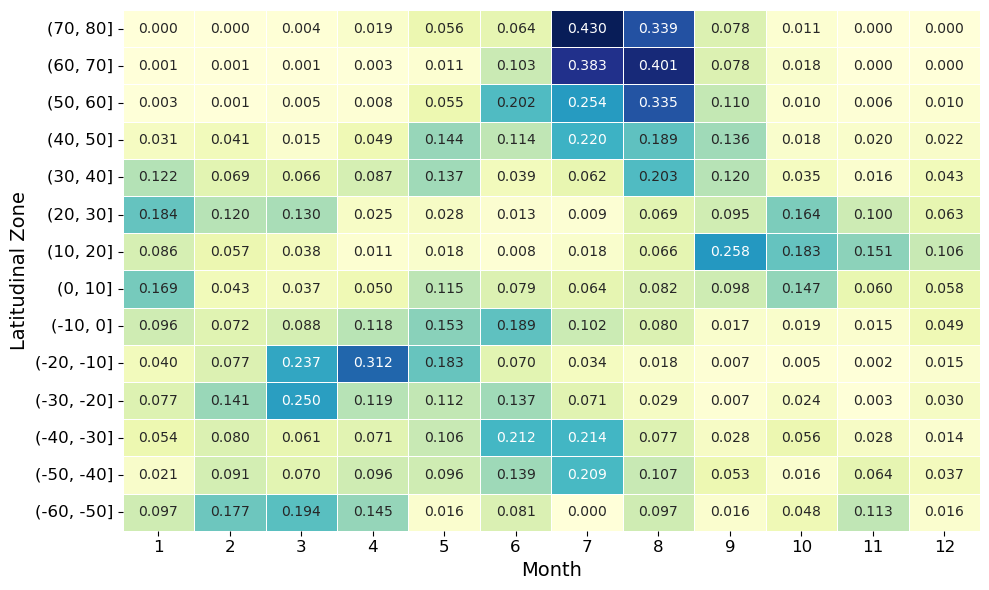

In [20]:
# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, cmap="YlGnBu", annot=True, fmt=".3f", linewidths=0.5, cbar=False
)
# plt.title("Heatmap of Proportions by Month and Latitudinal Zone")
plt.xlabel("Month", fontsize=14)
plt.ylabel("Latitudinal Zone", fontsize=14)


# publication quality - increased font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
# plt.show()

# save plot as vector graphics (svg or pdf)
plt.savefig("figure-s5.png", format="png", dpi=300)
plt.savefig("figure-s5.pdf", format="pdf")